In [5]:
import matplotlib.pyplot as plt
import torch
from vae import VAE, load_trained_improved_vae

In [2]:
latent_dim = 1024
device = "cpu"
num_samples = 10

In [3]:
model = VAE(latent_dim=latent_dim).to(device)

# Uncomment to load from checkpoint
model, start_epoch = load_trained_improved_vae(
    checkpoint_path="/home/fer/Escritorio/dragons/dragon/vae/VAE_TOTAL_7/best_improved_vae_best_epoch_500.pth",
    latent_dim=latent_dim,
    device=device,
)

Loaded checkpoint from epoch 499


In [4]:
z = torch.randn(num_samples, latent_dim, device=device)

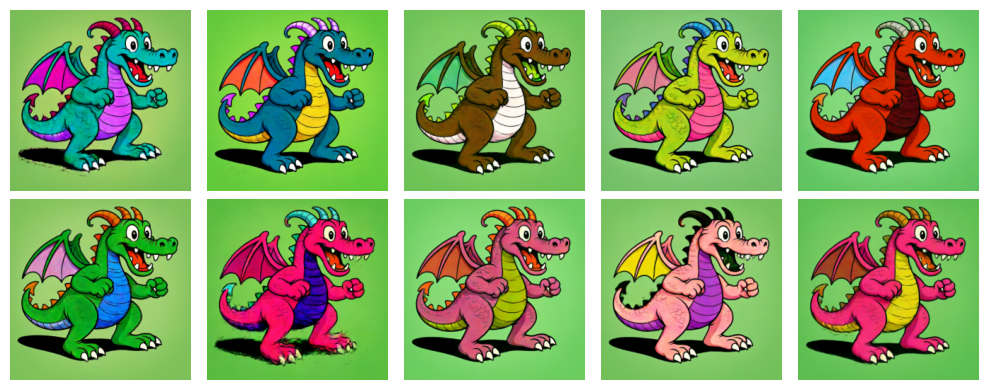

In [10]:
with torch.no_grad():
    recon = model.decode(z)

# Move to CPU, convert to numpy
recon = recon.cpu()

# Plot 2 rows × 5 columns
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.flatten()):
    img = recon[i].permute(1, 2, 0).numpy()  # [H, W, C]
    ax.imshow(img)
    ax.axis("off")

plt.tight_layout()
plt.show()

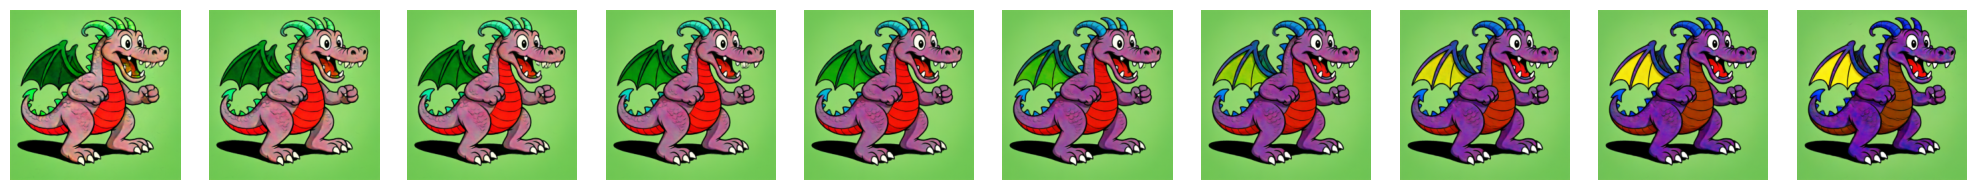

In [11]:
z1 = torch.randn(1, latent_dim, device=device)
z2 = torch.randn(1, latent_dim, device=device)

z1 = z1.unsqueeze(0) if z1.ndim == 1 else z1
z2 = z2.unsqueeze(0) if z2.ndim == 1 else z2

# Number of interpolation steps (e.g., 10 images)
n_steps = 10
alphas = torch.linspace(0, 1, n_steps).unsqueeze(1)  # [n_steps, 1]

# Interpolation
z_interp = (1 - alphas) * z1 + alphas * z2  # [n_steps, latent_dim]

# Decode
with torch.no_grad():
    recon = model.decode(z_interp)  # [n_steps, C, H, W]
recon = recon.cpu()

# Plot in a row
fig, axes = plt.subplots(1, n_steps, figsize=(2 * n_steps, 2))

for i, ax in enumerate(axes):
    img = recon[i].permute(1, 2, 0).numpy()
    ax.imshow(img.squeeze(), cmap="gray" if img.shape[-1] == 1 else None)
    ax.axis("off")

plt.tight_layout()
plt.show()

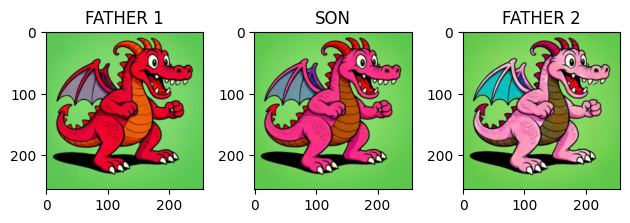

In [28]:
z1 = torch.randn(1, latent_dim, device=device)
z2 = torch.randn(1, latent_dim, device=device)

z1 = z1.unsqueeze(0) if z1.ndim == 1 else z1
z2 = z2.unsqueeze(0) if z2.ndim == 1 else z2
# Midpoint interpolation
z3 = (z1 + z2) / 2

# Decode it
with torch.no_grad():
    recon = model.decode(z3)  # [1, C, H, W]
    z1_recon = model.decode(z1)  # [1, C, H, W]
    z2_recon = model.decode(z2)  # [1, C, H, W]

fig, axes = plt.subplots(1, 3)

axes[0].imshow(
    z1_recon[0].cpu().permute(1, 2, 0).numpy().squeeze(),
    cmap="gray" if img.shape[-1] == 1 else None,
)
axes[0].set_title("FATHER 1")
axes[1].imshow(
    recon[0].cpu().permute(1, 2, 0).numpy().squeeze(),
    cmap="gray" if img.shape[-1] == 1 else None,
)
axes[1].set_title("SON")
axes[2].imshow(
    z2_recon[0].cpu().permute(1, 2, 0).numpy().squeeze(),
    cmap="gray" if img.shape[-1] == 1 else None,
)
axes[2].set_title("FATHER 2")

plt.tight_layout()
plt.show()

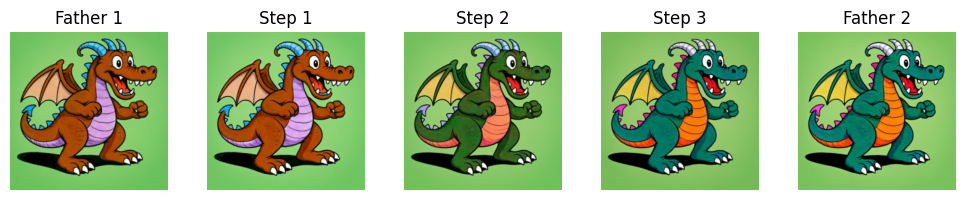

In [40]:
import matplotlib.pyplot as plt
import torch

# Generate latent vectors
z1 = torch.randn(1, latent_dim, device=device)
z2 = torch.randn(1, latent_dim, device=device)

# Ensure batch dimension
z1 = z1.unsqueeze(0) if z1.ndim == 1 else z1
z2 = z2.unsqueeze(0) if z2.ndim == 1 else z2

# Interpolation steps
n_steps = 3
alphas = torch.linspace(0, 1, n_steps).unsqueeze(1)  # [n_steps, 1]

# Linear interpolation
z_interp = (1 - alphas) * z1 + alphas * z2  # [n_steps, latent_dim]

# Decode
with torch.no_grad():
    recon_interp = model.decode(z_interp).cpu()  # [n_steps, C, H, W]
    z1_recon = model.decode(z1).cpu()  # [1, C, H, W]
    z2_recon = model.decode(z2).cpu()  # [1, C, H, W]

# Plot parents + interpolations
total_imgs = n_steps + 2  # parents + interpolated images
fig, axes = plt.subplots(1, total_imgs, figsize=(2 * total_imgs, 2))

# Father 1
img = z1_recon[0].permute(1, 2, 0).numpy()
axes[0].imshow(img.squeeze(), cmap="gray" if img.shape[-1] == 1 else None)
axes[0].set_title("Father 1")
axes[0].axis("off")

# Interpolated images
for i in range(n_steps):
    img = recon_interp[i].permute(1, 2, 0).numpy()
    axes[i + 1].imshow(img.squeeze(), cmap="gray" if img.shape[-1] == 1 else None)
    axes[i + 1].set_title(f"Step {i + 1}")
    axes[i + 1].axis("off")

# Father 2
img = z2_recon[0].permute(1, 2, 0).numpy()
axes[-1].imshow(img.squeeze(), cmap="gray" if img.shape[-1] == 1 else None)
axes[-1].set_title("Father 2")
axes[-1].axis("off")

plt.tight_layout()
plt.show()